<a href="https://colab.research.google.com/github/hunkim98/earth_science/blob/main/lecture/EPS210_Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harvard EPS-210 AI for Earth and Planetary Science

Instructor: Mostafa Mouasvi

# Lab 10: Uncertainty Quantification in Deep Learning for Earth Sciences

## From Ensembles to Evidential Deep Learning

---

### Learning Objectives

1. Understand why **uncertainty quantification (UQ)** is critical in Earth science predictions
2. Distinguish **aleatoric uncertainty** (irreducible data noise) from **epistemic uncertainty** (model ignorance)
3. Implement and compare five UQ methods: deterministic baselines, **Gaussian (parametric)**, **MC Dropout**, **Deep Ensembles**, and **Evidential Deep Learning**
4. Apply these methods to two real Earth science problems: **seismic event classification** and **ground-motion regression**
5. Evaluate uncertainty quality with **calibration diagrams**, **reliability plots**, and **discard tests**

### Core Reference

**Schreck, J. S., Gagne, D. J., II, et al. (2024).** Evidential Deep Learning: Enhancing Predictive Uncertainty Estimation for Earth System Science Applications. *Artificial Intelligence for the Earth Systems*, 3(4). [arXiv:2309.13207](https://arxiv.org/abs/2309.13207)

### Why Uncertainty Matters in Earth Sciences

Every prediction in geophysics carries uncertainty: earthquake magnitude estimates, weather forecasts, volcanic eruption warnings, tsunami arrival times. A prediction without uncertainty is incomplete — and potentially dangerous. A seismic early warning system that reports "magnitude 6.5" is far less useful than one reporting "magnitude 6.5 ± 0.3, with high model confidence" or "magnitude 6.5 ± 0.3, but the model is uncertain because this event looks unlike training data."

This lab teaches you to build **neural networks that know what they don't know**.

---
## Part 1: Background — Types of Uncertainty

### 1.1 Aleatoric vs Epistemic Uncertainty

The **total predictive uncertainty** of any model can be decomposed into two fundamentally different components:

**Aleatoric uncertainty** (from Greek *alea* = dice) arises from inherent randomness in the data:
- Sensor noise in seismometers
- Chaotic atmospheric dynamics
- Stochastic rupture processes in earthquakes
- *Cannot be reduced* by collecting more training data

**Epistemic uncertainty** (from Greek *episteme* = knowledge) arises from model limitations:
- Insufficient training data in some input regions
- Model architecture choices
- Out-of-distribution inputs the model hasn't seen
- *Can be reduced* with more data or better models

The **Law of Total Variance** gives the decomposition:

$$\text{Total Uncertainty} = \underbrace{\mathbb{E}[\sigma^2]}_{\text{aleatoric}} + \underbrace{\text{Var}[\mu]}_{\text{epistemic}}$$

### 1.2 UQ Methods Compared in This Lab

| Method | # Models | Aleatoric | Epistemic | Key Idea |
|--------|----------|-----------|-----------|----------|
| Deterministic | 1 | ✗ | ✗ | Point estimate only |
| Gaussian (Parametric) | 1 | ✓ | ✗ | Predict μ and σ² |
| MC Dropout | 1 | ✓ | ✓ | Dropout at test time |
| Deep Ensemble | N | ✓ | ✓ | Train N independent models |
| **Evidential DL** | **1** | **✓** | **✓** | **Predict higher-order distribution** |

Evidential deep learning (Amini et al., 2020; Schreck et al., 2024) captures **both** uncertainty types with a **single** model by predicting the parameters of a higher-order distribution (Normal-Inverse-Gamma for regression, Dirichlet for classification).

---



In [ ]:
# @title Part 2: Environment Setup
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats, special
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')

PyTorch 2.10.0+cu128 | Device: cuda


---
## Part 3: Earth Science Dataset — Earthquake Ground-Motion Prediction

### The Problem

Predicting **Peak Ground Acceleration (PGA)** from earthquake source and path parameters is fundamental to seismic hazard assessment. Ground-Motion Prediction Equations (GMPEs) estimate shaking intensity from:

- **Magnitude** ($M_w$): Energy released at the source
- **Distance** ($R_{rup}$): Rupture distance to the site (km)
- **Depth** ($Z_{hyp}$): Hypocentral depth (km)
- **$V_{S30}$**: Average shear-wave velocity in the top 30 m (site amplification proxy)

This is a natural UQ problem: ground motion has large intrinsic scatter (aleatoric) due to complex wave propagation, and models are uncertain about rare large-magnitude, near-field events (epistemic).

We construct a realistic dataset based on the NGA-West2 functional form, adding heteroscedastic noise that increases with distance — mimicking real ground-motion variability.

In [ ]:
import numpy as np
# ============================================================
# Generate realistic earthquake ground-motion dataset
# Based on NGA-West2-style GMPE functional form
# ============================================================

def generate_ground_motion_data(n_samples=10000, seed=42, allow_large_near_events=False):
    """
    Generate earthquake ground-motion data based on simplified GMPE.

    Features: [Mw, log10(Rrup), log10(depth), log10(Vs30)]
    Target:   ln(PGA) in units of ln(g)

    Includes heteroscedastic aleatoric noise (larger at greater distances)
    and regions of sparse data (large Mw, short distance) for epistemic uncertainty.
    """
    rng = np.random.RandomState(seed)

    # --- Source parameters ---
    # Magnitude: Gutenberg-Richter distribution (more small events)
    Mw = rng.exponential(0.5, n_samples) + 3.0
    Mw = np.clip(Mw, 3.0, 8.5)
    # Remove some large-magnitude near-distance events (rare in nature)
    if not allow_large_near_events:
        large_near_mask = (Mw > 7.0) & (rng.rand(n_samples) > 0.15)
        Mw[large_near_mask] = rng.uniform(3.0, 6.5, large_near_mask.sum())

    # Rupture distance: log-uniform (more close events in catalog)
    log_Rrup = rng.uniform(np.log10(1), np.log10(500), n_samples)
    Rrup = 10**log_Rrup

    # Depth: bimodal (shallow crustal + deeper events)
    depth = np.where(rng.rand(n_samples) > 0.3,
                     rng.exponential(8, n_samples) + 2,
                     rng.uniform(30, 100, n_samples))
    depth = np.clip(depth, 1, 200)

    # Vs30: site conditions (log-normal around ~400 m/s)
    Vs30 = 10**(rng.normal(2.6, 0.25, n_samples))
    Vs30 = np.clip(Vs30, 150, 1500)

    # --- Ground-motion prediction (simplified NGA-West2 form) ---
    # ln(PGA) = c1 + c2*(M-6) + c3*(M-6)^2 + c4*ln(R+c5*exp(c6*M)) + c7*ln(Vs30/760) + c8*depth_term
    c1, c2, c3, c4, c5, c6, c7, c8 = -1.5, 0.9, -0.08, -1.2, 5.0, 0.8, -0.5, -0.003

    R_eff = np.sqrt(Rrup**2 + depth**2)  # Effective distance
    ln_PGA = (c1 + c2*(Mw - 6) + c3*(Mw - 6)**2 +
              c4 * np.log(R_eff + c5 * np.exp(c6 * Mw)) +
              c7 * np.log(Vs30 / 760) +
              c8 * depth)

    # --- Heteroscedastic noise (aleatoric uncertainty) ---
    # Sigma increases with distance and decreases with magnitude
    sigma_aleatoric = 0.3 + 0.15 * np.log10(Rrup/10) + 0.1 * np.maximum(0, 5.5 - Mw)
    sigma_aleatoric = np.clip(sigma_aleatoric, 0.2, 0.8)
    noise = rng.normal(0, sigma_aleatoric)
    ln_PGA_noisy = ln_PGA + noise

    # Features: [Mw, log10(Rrup), log10(depth), log10(Vs30)]
    X = np.column_stack([
        Mw,
        np.log10(Rrup),
        np.log10(depth),
        np.log10(Vs30)
    ]).astype(np.float32)
    y = ln_PGA_noisy.astype(np.float32)

    return X, y, sigma_aleatoric, Mw, Rrup, depth, Vs30


# Generate data
X_all, y_all, sigma_true, Mw_all, Rrup_all, depth_all, Vs30_all = \
    generate_ground_motion_data(n_samples=15000)

# Train/val/test split (60/20/20)
n = len(X_all)
idx = np.random.permutation(n)
n_train, n_val = int(0.6*n), int(0.2*n)

X_train = X_all[idx[:n_train]]
y_train = y_all[idx[:n_train]]
X_val = X_all[idx[n_train:n_train+n_val]]
y_val = y_all[idx[n_train:n_train+n_val]]
X_test = X_all[idx[n_train+n_val:]]
y_test = y_all[idx[n_train+n_val:]]
sigma_test = sigma_true[idx[n_train+n_val:]]
Mw_test = Mw_all[idx[n_train+n_val:]]
Rrup_test = Rrup_all[idx[n_train+n_val:]]

# Standardize features
X_mean, X_std = X_train.mean(0), X_train.std(0)
y_mean, y_std = y_train.mean(), y_train.std()
X_train_s = (X_train - X_mean) / X_std
X_val_s = (X_val - X_mean) / X_std
X_test_s = (X_test - X_mean) / X_std
y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std
y_test_s = (y_test - y_mean) / y_std

# Create out-of-distribution test set (large Mw, short distance — rare in training)
X_ood_raw, y_ood_raw, sigma_ood, Mw_ood, Rrup_ood, _, _ = generate_ground_motion_data(3000, seed=99, allow_large_near_events=True)
mask_ood = (Mw_ood > 7.0) & (Rrup_ood < 30)
X_ood = ((X_ood_raw[mask_ood] - X_mean) / X_std).astype(np.float32)
y_ood_s = ((y_ood_raw[mask_ood] - y_mean) / y_std).astype(np.float32)

print(f'Feature names: [Mw, log10(Rrup), log10(Depth), log10(Vs30)]')
print(f'Target: ln(PGA) — Peak Ground Acceleration')
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,} | OOD: {len(X_ood)}')
print(f'Mw range: {Mw_all.min():.1f}–{Mw_all.max():.1f}')
print(f'Rrup range: {Rrup_all.min():.1f}–{Rrup_all.max():.0f} km')
print(f'OOD Mw range: {Mw_ood[mask_ood].min():.1f}–{Mw_ood[mask_ood].max():.1f}')
print(f'OOD Rrup range: {Rrup_ood[mask_ood].min():.1f}–{Rrup_ood[mask_ood].max():.0f} km')

Feature names: [Mw, log10(Rrup), log10(Depth), log10(Vs30)]
Target: ln(PGA) — Peak Ground Acceleration
Train: 9,000 | Val: 3,000 | Test: 3,000 | OOD: 3
Mw range: 3.0–6.9
Rrup range: 1.0–500 km
OOD Mw range: 7.3–8.5
OOD Rrup range: 3.5–13 km


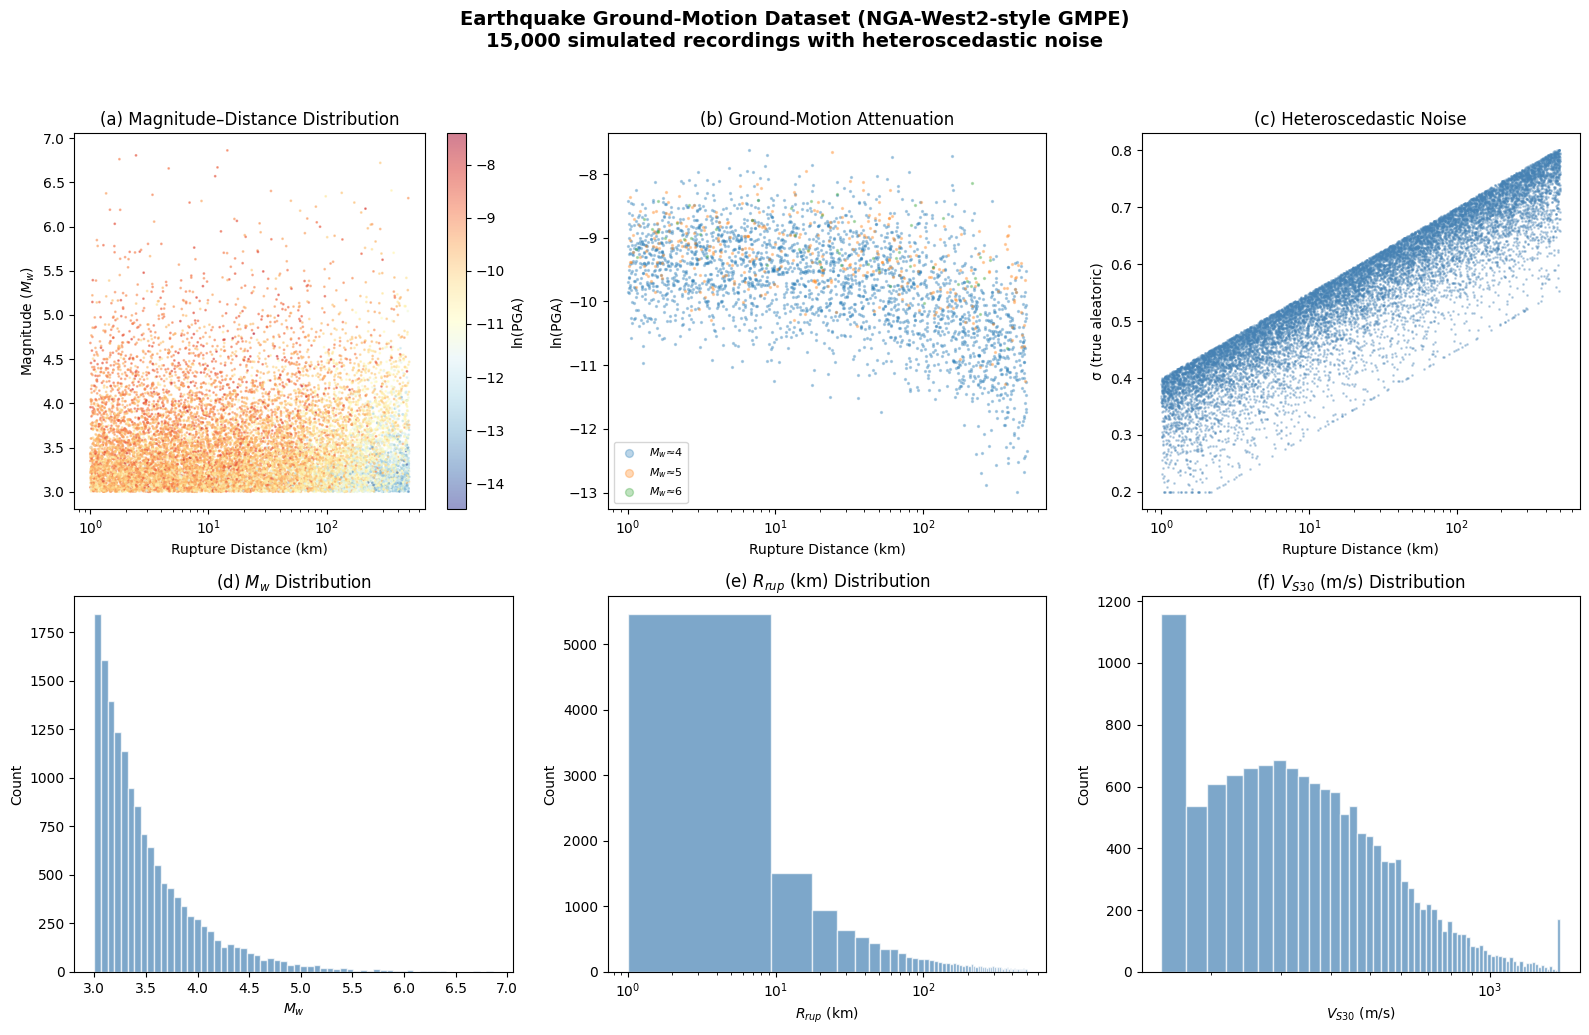

In [ ]:
# Visualize dataset
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (a) Magnitude-distance distribution
sc = axes[0,0].scatter(Rrup_all, Mw_all, c=y_all, s=1, cmap='RdYlBu_r', alpha=0.5)
axes[0,0].set_xscale('log'); axes[0,0].set_xlabel('Rupture Distance (km)')
axes[0,0].set_ylabel('Magnitude ($M_w$)')
axes[0,0].set_title('(a) Magnitude–Distance Distribution')
plt.colorbar(sc, ax=axes[0,0], label='ln(PGA)')

# (b) Distance attenuation curves
for m in [4.0, 5.0, 6.0, 7.0, 7.5]:
    mask = np.abs(Mw_all - m) < 0.3
    if mask.sum() > 10:
        axes[0,1].scatter(Rrup_all[mask], y_all[mask], s=2, alpha=0.3, label=f'$M_w$≈{m:.0f}')
axes[0,1].set_xscale('log')
axes[0,1].set_xlabel('Rupture Distance (km)'); axes[0,1].set_ylabel('ln(PGA)')
axes[0,1].set_title('(b) Ground-Motion Attenuation'); axes[0,1].legend(fontsize=8, markerscale=4)

# (c) True aleatoric noise vs distance
axes[0,2].scatter(Rrup_all, sigma_true, s=1, alpha=0.3, c='steelblue')
axes[0,2].set_xscale('log')
axes[0,2].set_xlabel('Rupture Distance (km)'); axes[0,2].set_ylabel('σ (true aleatoric)')
axes[0,2].set_title('(c) Heteroscedastic Noise')

# (d-f) Feature distributions
for i, (name, data) in enumerate([('$M_w$', Mw_all), ('$R_{rup}$ (km)', Rrup_all), ('$V_{S30}$ (m/s)', Vs30_all)]):
    axes[1,i].hist(data, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
    axes[1,i].set_xlabel(name); axes[1,i].set_ylabel('Count')
    axes[1,i].set_title(f'({"def"[i]}) {name} Distribution')
    if i > 0: axes[1,i].set_xscale('log')

fig.suptitle('Earthquake Ground-Motion Dataset (NGA-West2-style GMPE)\n'
             '15,000 simulated recordings with heteroscedastic noise',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

---
## Part 4: Method 1 — Deterministic Neural Network (Baseline)

The simplest approach: a standard MLP that predicts a **point estimate** of ln(PGA). No uncertainty — just a single number per prediction.

In [ ]:
class DeterministicMLP(nn.Module):
    """Standard MLP — no uncertainty estimation."""
    def __init__(self, in_dim=4, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_loaders(X_tr, y_tr, X_vl, y_vl, bs=256):
    tr = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)),
                    batch_size=bs, shuffle=True)
    vl = DataLoader(TensorDataset(torch.FloatTensor(X_vl), torch.FloatTensor(y_vl)),
                    batch_size=bs)
    return tr, vl


def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3,
                loss_fn=None, verbose=True):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)
    if loss_fn is None:
        loss_fn = nn.MSELoss()
    best_vl, best_state = 1e9, None
    hist = {'tl': [], 'vl': []}
    for ep in range(epochs):
        model.train(); tl = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb) if not isinstance(loss_fn, type) else loss_fn(model, xb, yb)
            loss.backward(); opt.step()
            tl += loss.item()
        model.eval(); vl = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vloss = loss_fn(model(xb), yb) if not isinstance(loss_fn, type) else loss_fn(model, xb, yb)
                vl += vloss.item()
        tl /= len(train_loader); vl /= len(val_loader)
        hist['tl'].append(tl); hist['vl'].append(vl)
        sched.step(vl)
        if vl < best_vl:
            best_vl = vl; best_state = copy.deepcopy(model.state_dict())
        if verbose and (ep+1) % 25 == 0:
            print(f'Ep {ep+1:3d} | Train {tl:.4f} | Val {vl:.4f}')
    model.load_state_dict(best_state)
    return hist


# Train deterministic model
train_loader, val_loader = make_loaders(X_train_s, y_train_s, X_val_s, y_val_s)
det_model = DeterministicMLP().to(device)
print('Training Deterministic MLP...')
det_hist = train_model(det_model, train_loader, val_loader, epochs=100)

# Evaluate
det_model.eval()
with torch.no_grad():
    y_pred_det = det_model(torch.FloatTensor(X_test_s).to(device)).cpu().numpy()

print(f'\nExample prediction ({y_pred_det[0]}) & grournd truth ({y_test_s[0]}) pair.')
rmse_det = np.sqrt(np.mean((y_pred_det - y_test_s)**2))
print(f'\nDeterministic RMSE (standardized): {rmse_det:.4f}')
print('⚠ No uncertainty estimate available!')

Training Deterministic MLP...
Ep  25 | Train 0.3518 | Val 0.3799
Ep  50 | Train 0.3497 | Val 0.3825
Ep  75 | Train 0.3402 | Val 0.3811
Ep 100 | Train 0.3441 | Val 0.3814

Example prediction (0.7068825364112854) & grournd truth (0.5533039569854736) pair.

Deterministic RMSE (standardized): 0.5920
⚠ No uncertainty estimate available!


## TODO: visualize the neural network

## TODO: plot learning curves


---
## Part 5: Method 2 — Gaussian (Parametric) Network

Instead of predicting a single value, the network predicts **two parameters**: the mean $\mu$ and variance $\sigma^2$ of a Gaussian distribution. Trained by minimizing the negative log-likelihood:

$$\mathcal{L}_{\text{NLL}} = \frac{1}{2}\log\sigma^2 + \frac{(y - \mu)^2}{2\sigma^2}$$

This captures **aleatoric uncertainty** (heteroscedastic noise) but not epistemic uncertainty — the model is always equally "confident" in its variance estimate, even for out-of-distribution inputs.

In [ ]:
class GaussianMLP(nn.Module):
    """Predicts μ and σ² — captures aleatoric uncertainty only."""
    def __init__(self, in_dim=4, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.backbone = nn.Sequential(*layers)
        self.mu_head = nn.Linear(hidden, 1)
        self.logvar_head = nn.Linear(hidden, 1)  # predict log(σ²) for stability

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mu_head(h).squeeze(-1)
        logvar = self.logvar_head(h).squeeze(-1)
        return mu, logvar


def gaussian_nll_loss(model_output, y):
    mu, logvar = model_output
    var = torch.exp(logvar) + 1e-6
    return torch.mean(0.5 * logvar + 0.5 * (y - mu)**2 / var)


gauss_model = GaussianMLP().to(device)
print('Training Gaussian MLP...')
gauss_hist = train_model(gauss_model, train_loader, val_loader,
                         epochs=100, loss_fn=gaussian_nll_loss)

gauss_model.eval()
with torch.no_grad():
    mu_g, logvar_g = gauss_model(torch.FloatTensor(X_test_s).to(device))
    y_pred_gauss = mu_g.cpu().numpy()
    sigma_gauss = np.sqrt(np.exp(logvar_g.cpu().numpy()))

print(f'\nExample prediction ({y_pred_gauss[0]} ± {sigma_gauss[0]}) & grournd truth ({y_test_s[0]}) pair.')
rmse_gauss = np.sqrt(np.mean((y_pred_gauss - y_test_s)**2))
print(f'\nGaussian RMSE: {rmse_gauss:.4f}')
print(f'Mean predicted σ: {sigma_gauss.mean():.4f}')
print('✓ Aleatoric uncertainty captured | ✗ No epistemic uncertainty')

Training Gaussian MLP...
Ep  25 | Train -0.0864 | Val -0.0405
Ep  50 | Train -0.0985 | Val -0.0410
Ep  75 | Train -0.1053 | Val -0.0378
Ep 100 | Train -0.1066 | Val -0.0378

Example prediction (0.7118962407112122 ± 0.39543598890304565) & grournd truth (0.5533039569854736) pair.

Gaussian RMSE: 0.5936
Mean predicted σ: 0.5851
✓ Aleatoric uncertainty captured | ✗ No epistemic uncertainty


---
## Part 6: Method 3 — MC Dropout

MC Dropout (Gal & Ghahramani, 2016) is a practical Bayesian approximation: keep dropout **active at test time** and run multiple forward passes. The variation across passes estimates epistemic uncertainty.

$$\mu^* = \frac{1}{T}\sum_{t=1}^T f_{\hat{w}_t}(x), \quad \sigma^2_{\text{epistemic}} = \text{Var}_t[f_{\hat{w}_t}(x)]$$

where $\hat{w}_t$ are the weights with different dropout masks.

In [ ]:
class MCDropoutMLP(nn.Module):
    """Gaussian MLP with dropout kept active at test time."""
    def __init__(self, in_dim=4, hidden=128, n_layers=3, dropout=0.1):
        super().__init__()
        layers = []
        layers += [nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.backbone = nn.Sequential(*layers)
        self.mu_head = nn.Linear(hidden, 1)
        self.logvar_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mu_head(h).squeeze(-1)
        logvar = self.logvar_head(h).squeeze(-1)
        return mu, logvar

    def predict_mc(self, x, T=50):
        """T stochastic forward passes with dropout active."""
        self.train()  # Keep dropout ON
        mus, sigmas = [], []
        with torch.no_grad():
            for _ in range(T):
                mu, logvar = self(x)
                mus.append(mu.cpu().numpy())
                sigmas.append(np.sqrt(np.exp(logvar.cpu().numpy())))
        mus = np.array(mus)
        sigmas = np.array(sigmas)
        # Law of Total Variance decomposition
        pred_mean = mus.mean(0)
        aleatoric = (sigmas**2).mean(0)    # E[σ²]
        epistemic = mus.var(0)              # Var[μ]
        total = aleatoric + epistemic
        return pred_mean, np.sqrt(aleatoric), np.sqrt(epistemic), np.sqrt(total)


def mcdropout_nll_loss(model_output, y):
    mu, logvar = model_output
    var = torch.exp(logvar) + 1e-6
    return torch.mean(0.5 * logvar + 0.5 * (y - mu)**2 / var)


mc_model = MCDropoutMLP(dropout=0.1).to(device)
print('Training MC Dropout MLP...')
mc_hist = train_model(mc_model, train_loader, val_loader,
                      epochs=100, loss_fn=mcdropout_nll_loss)

# MC inference with T=50 passes
x_test_t = torch.FloatTensor(X_test_s).to(device)
y_pred_mc, sigma_al_mc, sigma_ep_mc, sigma_tot_mc = mc_model.predict_mc(x_test_t, T=50)

print(f'\nExample prediction ({y_pred_mc[0]} ± {sigma_tot_mc[0]} (Al: {sigma_al_mc[0]}, Eps: {sigma_ep_mc[0]})) & grournd truth ({y_test_s[0]}) pair.')

rmse_mc = np.sqrt(np.mean((y_pred_mc - y_test_s)**2))
print(f'\nMC Dropout RMSE: {rmse_mc:.4f}')
print(f'Mean aleatoric σ: {sigma_al_mc.mean():.4f} | Mean epistemic σ: {sigma_ep_mc.mean():.4f}')
print('✓ Aleatoric + Epistemic uncertainty (via 50 forward passes)')

Training MC Dropout MLP...
Ep  25 | Train -0.0630 | Val -0.0434
Ep  50 | Train -0.0736 | Val -0.0418
Ep  75 | Train -0.0783 | Val -0.0434
Ep 100 | Train -0.0793 | Val -0.0430

Example prediction (0.7082195281982422 ± 0.4207182824611664 (Al: 0.4138511121273041, Eps: 0.0757041797041893)) & grournd truth (0.5533039569854736) pair.

MC Dropout RMSE: 0.5913
Mean aleatoric σ: 0.5853 | Mean epistemic σ: 0.0948
✓ Aleatoric + Epistemic uncertainty (via 50 forward passes)


---
## Part 7: Method 4 — Deep Ensemble

Deep Ensembles (Lakshminarayanan et al., 2017) train **N independent models** with different random initializations. Each member captures aleatoric uncertainty (via Gaussian output), and the disagreement across members captures epistemic uncertainty.

This is the gold standard for UQ — but requires training and storing N separate models.

In [ ]:
N_ENSEMBLE = 5

ensemble_models = []
print(f'Training Deep Ensemble ({N_ENSEMBLE} members)...')
for i in range(N_ENSEMBLE):
    torch.manual_seed(i * 42 + 7)  # Different initialization
    m = GaussianMLP().to(device)
    train_model(m, train_loader, val_loader, epochs=100,
                loss_fn=gaussian_nll_loss, verbose=False)
    ensemble_models.append(m)
    print(f'  Member {i+1}/{N_ENSEMBLE} trained')

# Ensemble inference
def predict_ensemble(models, x):
    mus, sigmas = [], []
    for m in models:
        m.eval()
        with torch.no_grad():
            mu, logvar = m(x)
            mus.append(mu.cpu().numpy())
            sigmas.append(np.sqrt(np.exp(logvar.cpu().numpy())))
    mus = np.array(mus)
    sigmas = np.array(sigmas)
    pred_mean = mus.mean(0)
    aleatoric = (sigmas**2).mean(0)
    epistemic = mus.var(0)
    total = aleatoric + epistemic
    return pred_mean, np.sqrt(aleatoric), np.sqrt(epistemic), np.sqrt(total)

y_pred_ens, sigma_al_ens, sigma_ep_ens, sigma_tot_ens = predict_ensemble(
    ensemble_models, x_test_t)

print(f'\nExample prediction ({y_pred_ens[0]} ± {sigma_tot_ens[0]} (Al: {sigma_al_ens[0]}, Eps:{sigma_ep_ens[0]})) & grournd truth ({y_test_s[0]}) pair.')

rmse_ens = np.sqrt(np.mean((y_pred_ens - y_test_s)**2))
print(f'\nEnsemble RMSE: {rmse_ens:.4f}')
print(f'Mean aleatoric σ: {sigma_al_ens.mean():.4f} | Mean epistemic σ: {sigma_ep_ens.mean():.4f}')
print(f'✓ Gold standard — but requires {N_ENSEMBLE}× training cost')

Training Deep Ensemble (5 members)...
  Member 1/5 trained
  Member 2/5 trained
  Member 3/5 trained
  Member 4/5 trained
  Member 5/5 trained

Example prediction (0.7002176642417908 ± 0.40995708107948303 (Al: 0.409278929233551, Eps:0.023570425808429718)) & grournd truth (0.5533039569854736) pair.

Ensemble RMSE: 0.5918
Mean aleatoric σ: 0.5888 | Mean epistemic σ: 0.0304
✓ Gold standard — but requires 5× training cost


---
## Part 8: Method 5 — Evidential Deep Learning (EDL)

### The Key Innovation

Instead of predicting the parameters of a Gaussian $(\mu, \sigma^2)$ directly, an evidential network predicts the parameters of a **higher-order distribution** — the **Normal-Inverse-Gamma (NIG)** — which is a distribution *over* Gaussian parameters.

The NIG distribution is parameterized by four values $(\gamma, \nu, \alpha, \beta)$:

$$p(\mu, \sigma^2 \mid \gamma, \nu, \alpha, \beta) = \frac{\beta^\alpha \sqrt{\nu}}{\Gamma(\alpha)\sqrt{2\pi\sigma^2}} \left(\frac{1}{\sigma^2}\right)^{\alpha+1} \exp\left\{-\frac{2\beta + \nu(\gamma - \mu)^2}{2\sigma^2}\right\}$$

From these, we extract:

| Quantity | Formula | Meaning |
|----------|---------|--------|
| Prediction | $\mathbb{E}[\mu] = \gamma$ | Best estimate |
| Aleatoric | $\mathbb{E}[\sigma^2] = \frac{\beta}{\alpha - 1}$ | Data noise |
| Epistemic | $\text{Var}[\mu] = \frac{\beta}{\nu(\alpha - 1)}$ | Model ignorance |

The parameters $\nu$ and $\alpha$ act as "virtual observation counts" — more evidence → lower epistemic uncertainty.

### The NIG Loss

$$\mathcal{L}_{\text{NIG}} = \underbrace{\mathcal{L}_{\text{NLL}}}_{\text{fit data}} + \lambda \cdot \underbrace{\mathcal{L}_{\text{Reg}}}_{\text{regularize evidence}}$$

The regularization term penalizes high evidence when predictions are wrong — ensuring the model doesn't become overconfident on errors.

In [ ]:
class EvidentialMLP(nn.Module):
    """
    Evidential Regression Network (Amini et al., 2020; Schreck et al., 2024).
    Predicts NIG parameters (γ, ν, α, β) for each input.
    """
    def __init__(self, in_dim=4, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.backbone = nn.Sequential(*layers)
        self.gamma_head = nn.Linear(hidden, 1)  # μ prediction (linear)
        self.nu_head = nn.Linear(hidden, 1)      # ν > 0 (softplus)
        self.alpha_head = nn.Linear(hidden, 1)   # α > 1 (softplus + 1)
        self.beta_head = nn.Linear(hidden, 1)    # β > 0 (softplus)

    def forward(self, x):
        h = self.backbone(x)
        gamma = self.gamma_head(h).squeeze(-1)
        nu = F.softplus(self.nu_head(h).squeeze(-1)) + 1e-6
        alpha = F.softplus(self.alpha_head(h).squeeze(-1)) + 1.0 + 1e-6  # α > 1
        beta = F.softplus(self.beta_head(h).squeeze(-1)) + 1e-6
        return gamma, nu, alpha, beta

    def predict(self, x):
        """Extract prediction and uncertainty from NIG parameters."""
        gamma, nu, alpha, beta = self(x)
        prediction = gamma
        aleatoric = beta / (alpha - 1)       # E[σ²]
        epistemic = beta / (nu * (alpha - 1)) # Var[μ]
        return prediction, aleatoric, epistemic


def nig_nll(y, gamma, nu, alpha, beta):
    """Negative log-likelihood of the NIG distribution."""
    omega = 2 * beta * (1 + nu)
    nll = (0.5 * torch.log(np.pi / nu)
           - alpha * torch.log(omega)
           + (alpha + 0.5) * torch.log(nu * (y - gamma)**2 + omega)
           + torch.lgamma(alpha) - torch.lgamma(alpha + 0.5))
    return nll.mean()


def nig_reg(y, gamma, nu, alpha, beta):
    """Regularization: penalize evidence when prediction is wrong."""
    error = torch.abs(y - gamma)
    evidence = 2 * nu + alpha
    return (error * evidence).mean()


def evidential_loss(gamma, nu, alpha, beta, y, lamb=0.05):
    """Combined NIG loss: NLL + λ * regularization."""
    return nig_nll(y, gamma, nu, alpha, beta) + lamb * nig_reg(y, gamma, nu, alpha, beta)


# Train evidential model
evd_model = EvidentialMLP().to(device)
print('Training Evidential Deep Learning MLP...')
evd_hist = train_model(evd_model, train_loader, val_loader,
                       epochs=150, loss_fn=lambda model_output_tuple, y_true: evidential_loss(*model_output_tuple, y_true, lamb=0.05))

# Inference — single forward pass!
evd_model.eval()
with torch.no_grad():
    y_pred_evd, al_var_evd, ep_var_evd = evd_model.predict(x_test_t)
    y_pred_evd = y_pred_evd.cpu().numpy()
    sigma_al_evd = np.sqrt(al_var_evd.cpu().numpy())
    sigma_ep_evd = np.sqrt(ep_var_evd.cpu().numpy())
    sigma_tot_evd = np.sqrt(al_var_evd.cpu().numpy() + ep_var_evd.cpu().numpy())

print(f'\nExample prediction ({y_pred_evd[0]} ± {sigma_tot_evd[0]} (Al: {sigma_al_evd[0]}, Eps:{sigma_ep_evd[0]})) & grournd truth ({y_test_s[0]}) pair.')

rmse_evd = np.sqrt(np.mean((y_pred_evd - y_test_s)**2))
print(f'\nEvidential RMSE: {rmse_evd:.4f}')
print(f'Mean aleatoric σ: {sigma_al_evd.mean():.4f} | Mean epistemic σ: {sigma_ep_evd.mean():.4f}')
print('✓ Aleatoric + Epistemic from a SINGLE forward pass!')

Training Evidential Deep Learning MLP...
Ep  25 | Train 0.9054 | Val 0.9578
Ep  50 | Train 0.8901 | Val 0.9540
Ep  75 | Train 0.8842 | Val 0.9566
Ep 100 | Train 0.8768 | Val 0.9553
Ep 125 | Train 0.8778 | Val 0.9555
Ep 150 | Train 0.8816 | Val 0.9556

Example prediction (0.6870623826980591 ± 0.4823911786079407 (Al: 0.06491119414567947, Eps:0.47800394892692566)) & grournd truth (0.5533039569854736) pair.

Evidential RMSE: 0.5931
Mean aleatoric σ: 0.1006 | Mean epistemic σ: 0.7220
✓ Aleatoric + Epistemic from a SINGLE forward pass!


---
## Part 9: Head-to-Head Comparison

Following Schreck et al. (2024), we evaluate all methods on:
1. **Prediction accuracy** (RMSE)
2. **Uncertainty–error correlation** — does uncertainty increase where errors are large?
3. **Calibration** — are 95% prediction intervals actually 95%?
4. **Out-of-distribution detection** — does epistemic uncertainty flag OOD inputs?

In [ ]:
# ============================================================
# Summary table
# ============================================================
print(f'{"Method":<22} {"RMSE":>8} {"Mean σ_al":>10} {"Mean σ_ep":>10} {"Mean σ_tot":>10} {"# Models":>10}')
print('='*72)
print(f'{"Deterministic":<22} {rmse_det:8.4f} {"—":>10} {"—":>10} {"—":>10} {"1":>10}')
print(f'{"Gaussian":<22} {rmse_gauss:8.4f} {sigma_gauss.mean():10.4f} {"—":>10} {sigma_gauss.mean():10.4f} {"1":>10}')
print(f'{"MC Dropout (T=50)":<22} {rmse_mc:8.4f} {sigma_al_mc.mean():10.4f} {sigma_ep_mc.mean():10.4f} {sigma_tot_mc.mean():10.4f} {"1":>10}')
print(f'{"Deep Ensemble (N=5)":<22} {rmse_ens:8.4f} {sigma_al_ens.mean():10.4f} {sigma_ep_ens.mean():10.4f} {sigma_tot_ens.mean():10.4f} {"5":>10}')
print(f'{"Evidential DL":<22} {rmse_evd:8.4f} {sigma_al_evd.mean():10.4f} {sigma_ep_evd.mean():10.4f} {sigma_tot_evd.mean():10.4f} {"1":>10}')

Method                     RMSE  Mean σ_al  Mean σ_ep Mean σ_tot   # Models
Deterministic            0.5920          —          —          —          1
Gaussian                 0.5936     0.5851          —     0.5851          1
MC Dropout (T=50)        0.5913     0.5853     0.0948     0.5939          1
Deep Ensemble (N=5)      0.5918     0.5888     0.0304     0.5898          5
Evidential DL            0.5931     0.1006     0.7220     0.7297          1


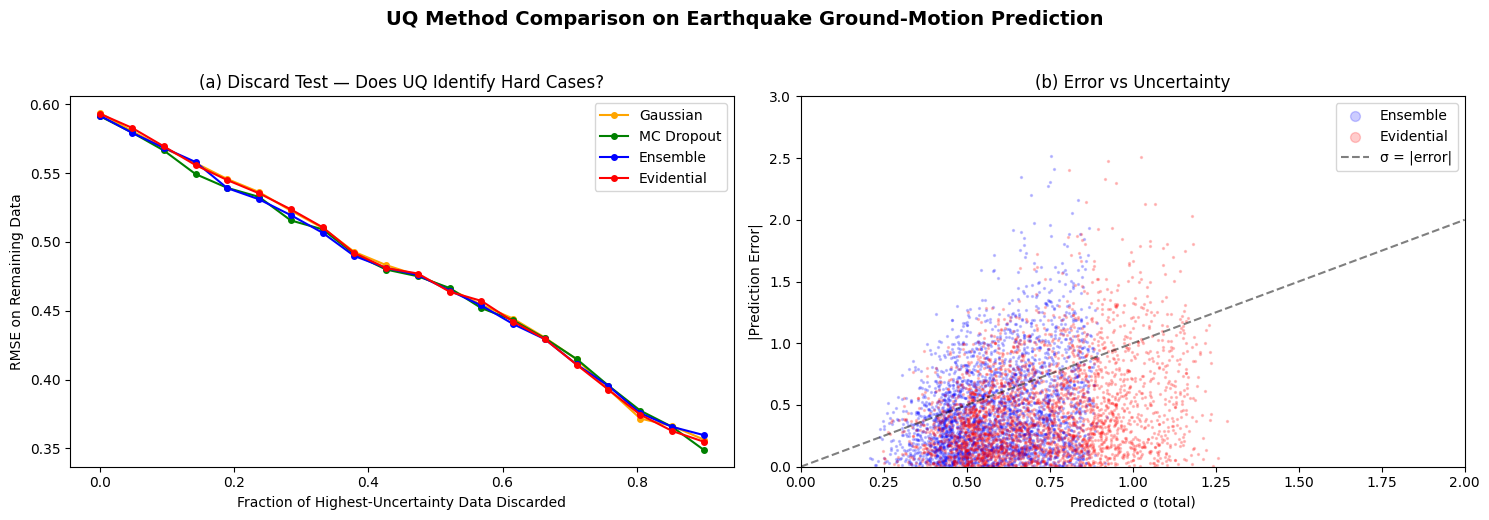

In [ ]:
# ============================================================
# Uncertainty–Error Correlation (Discard Test)
# If uncertainty is meaningful, discarding high-uncertainty
# predictions should improve RMSE.
# ============================================================

def discard_test(y_true, y_pred, sigma, label, n_bins=20):
    """Discard highest-uncertainty predictions and measure RMSE improvement."""
    fracs = np.linspace(0, 0.9, n_bins)
    rmses = []
    for f in fracs:
        threshold = np.percentile(sigma, (1-f)*100)
        keep = sigma <= threshold
        if keep.sum() > 10:
            rmses.append(np.sqrt(np.mean((y_true[keep] - y_pred[keep])**2)))
        else:
            rmses.append(np.nan)
    return fracs, rmses

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Discard test: RMSE vs fraction discarded
for name, ypred, sigma, color in [
    ('Gaussian', y_pred_gauss, sigma_gauss, 'orange'),
    ('MC Dropout', y_pred_mc, sigma_tot_mc, 'green'),
    ('Ensemble', y_pred_ens, sigma_tot_ens, 'blue'),
    ('Evidential', y_pred_evd, sigma_tot_evd, 'red'),
]:
    fracs, rmses = discard_test(y_test_s, ypred, sigma, name)
    axes[0].plot(fracs, rmses, '-o', label=name, color=color, ms=4)

axes[0].set_xlabel('Fraction of Highest-Uncertainty Data Discarded')
axes[0].set_ylabel('RMSE on Remaining Data')
axes[0].set_title('(a) Discard Test — Does UQ Identify Hard Cases?')
axes[0].legend()

# (b) Error vs predicted uncertainty scatter
abs_err_evd = np.abs(y_pred_evd - y_test_s)
abs_err_ens = np.abs(y_pred_ens - y_test_s)
axes[1].scatter(sigma_tot_ens, abs_err_ens, s=2, alpha=0.2, c='blue', label='Ensemble')
axes[1].scatter(sigma_tot_evd, abs_err_evd, s=2, alpha=0.2, c='red', label='Evidential')
axes[1].plot([0, 2], [0, 2], 'k--', alpha=0.5, label='σ = |error|')
axes[1].set_xlabel('Predicted σ (total)'); axes[1].set_ylabel('|Prediction Error|')
axes[1].set_title('(b) Error vs Uncertainty'); axes[1].legend(markerscale=5)
axes[1].set_xlim(0, 2); axes[1].set_ylim(0, 3)

fig.suptitle('UQ Method Comparison on Earthquake Ground-Motion Prediction',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

## TODO: make an Error vs Uncertainty plot but using the epistemic uncertainty only.

---
## Part 10: Uncertainty Decomposition — Physical Interpretability

Now we analyze how uncertainty varies with physical input parameters. This reveals which conditions produce high aleatoric noise (inherent variability) vs high epistemic uncertainty (model ignorance).

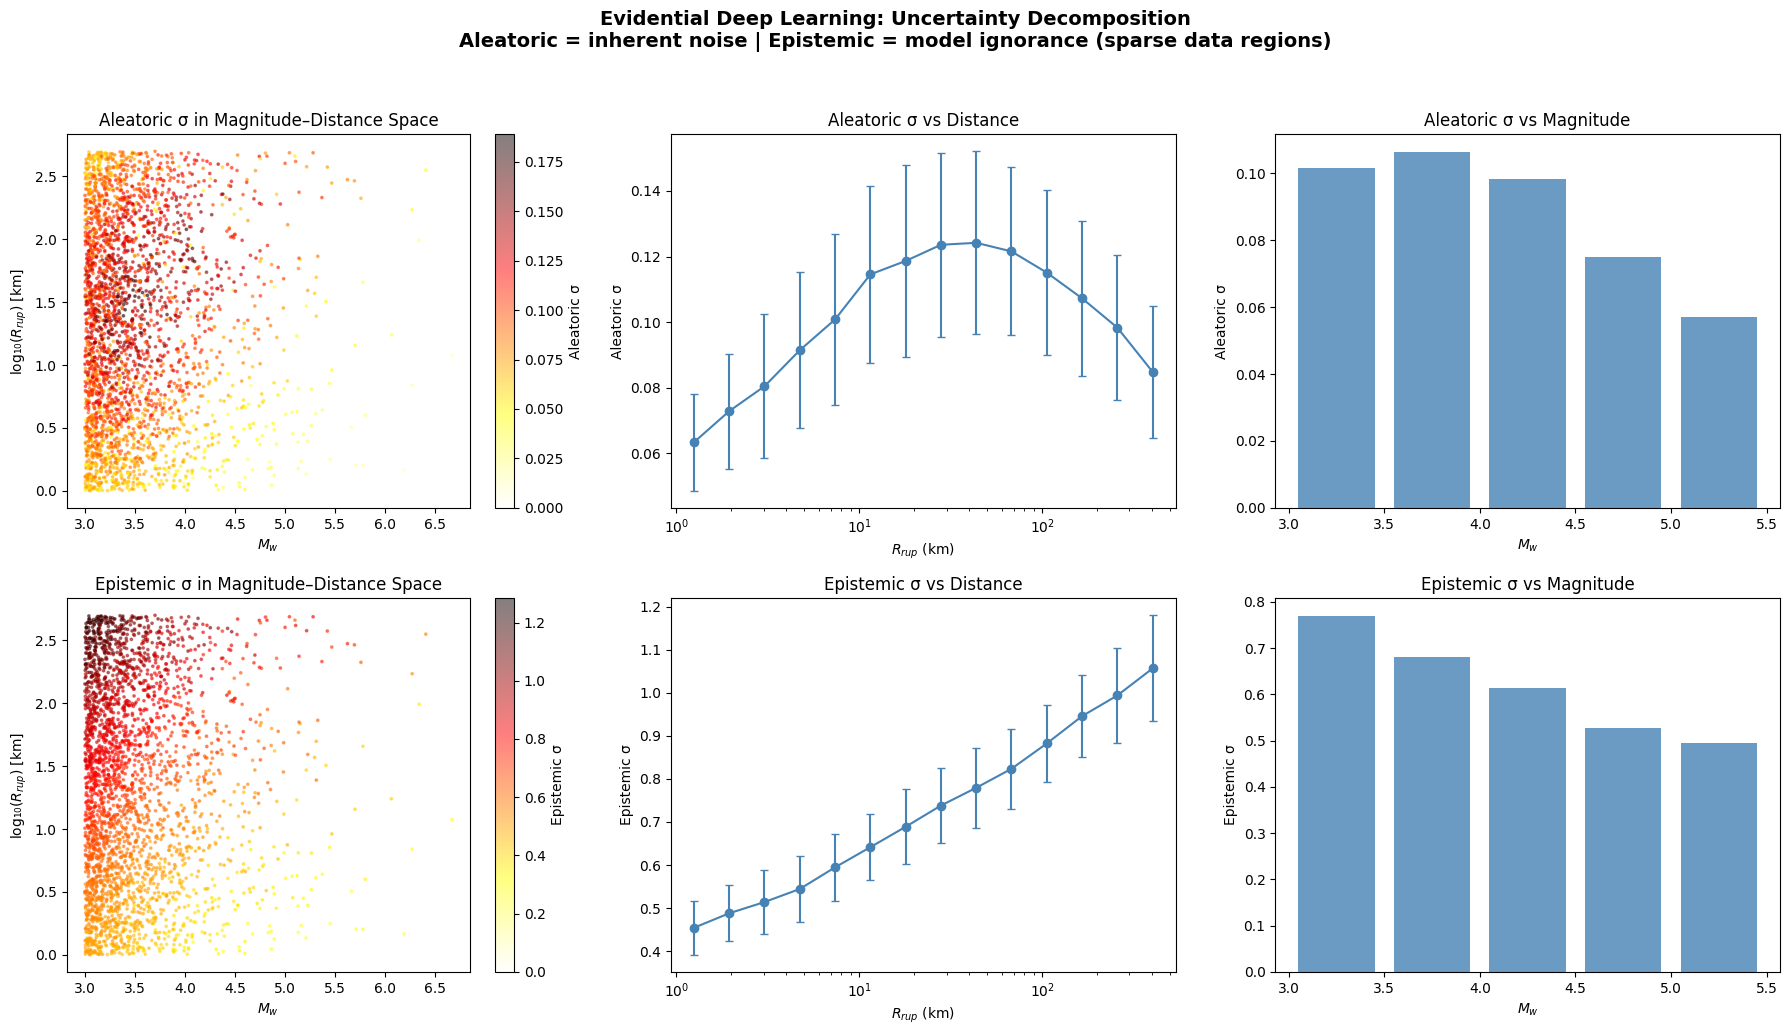

In [ ]:
# ============================================================
# Evidential uncertainty decomposition in physical space
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: Aleatoric uncertainty
# Row 1: Epistemic uncertainty
for row, (sigma_type, label) in enumerate([(sigma_al_evd, 'Aleatoric σ'),
                                            (sigma_ep_evd, 'Epistemic σ')]):
    # vs Magnitude
    sc0 = axes[row,0].scatter(Mw_test, np.log10(Rrup_test), c=sigma_type,
                              s=3, cmap='hot_r', alpha=0.5, vmin=0)
    axes[row,0].set_xlabel('$M_w$'); axes[row,0].set_ylabel('log₁₀($R_{rup}$) [km]')
    axes[row,0].set_title(f'{label} in Magnitude–Distance Space')
    plt.colorbar(sc0, ax=axes[row,0], label=label)

    # vs Distance (binned)
    dist_bins = np.logspace(0, 2.7, 15)
    bin_centers, bin_means, bin_stds = [], [], []
    for i in range(len(dist_bins)-1):
        mask = (Rrup_test >= dist_bins[i]) & (Rrup_test < dist_bins[i+1])
        if mask.sum() > 10:
            bin_centers.append(np.sqrt(dist_bins[i]*dist_bins[i+1]))
            bin_means.append(sigma_type[mask].mean())
            bin_stds.append(sigma_type[mask].std())
    axes[row,1].errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-',
                         color='steelblue', capsize=3)
    axes[row,1].set_xscale('log')
    axes[row,1].set_xlabel('$R_{rup}$ (km)'); axes[row,1].set_ylabel(label)
    axes[row,1].set_title(f'{label} vs Distance')

    # vs Magnitude (binned)
    mag_bins = np.arange(3, 8.5, 0.5)
    bin_centers_m, bin_means_m = [], []
    for i in range(len(mag_bins)-1):
        mask = (Mw_test >= mag_bins[i]) & (Mw_test < mag_bins[i+1])
        if mask.sum() > 10:
            bin_centers_m.append((mag_bins[i]+mag_bins[i+1])/2)
            bin_means_m.append(sigma_type[mask].mean())
    axes[row,2].bar(bin_centers_m, bin_means_m, width=0.4, color='steelblue', alpha=0.8)
    axes[row,2].set_xlabel('$M_w$'); axes[row,2].set_ylabel(label)
    axes[row,2].set_title(f'{label} vs Magnitude')

fig.suptitle('Evidential Deep Learning: Uncertainty Decomposition\n'
             'Aleatoric = inherent noise | Epistemic = model ignorance (sparse data regions)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

---
## Part 11: Out-of-Distribution Detection

Does epistemic uncertainty increase for inputs the model hasn't seen? We test with **large-magnitude, near-field events** — rare in the training set but crucial for seismic hazard.

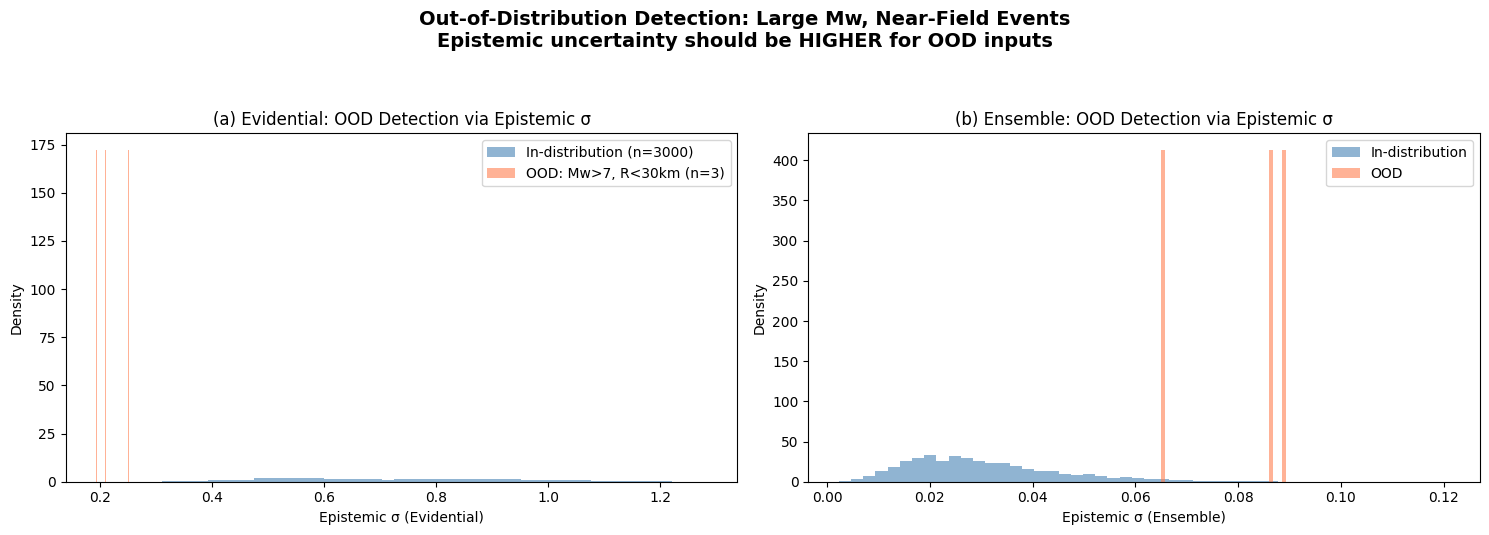

In [ ]:
# Predict on OOD data (large Mw, short distance)
x_ood_t = torch.FloatTensor(X_ood).to(device)

# Evidential on OOD
evd_model.eval()
with torch.no_grad():
    _, al_ood, ep_ood = evd_model.predict(x_ood_t)
    sigma_al_ood = np.sqrt(al_ood.cpu().numpy())
    sigma_ep_ood = np.sqrt(ep_ood.cpu().numpy())

# Ensemble on OOD
_, sigma_al_ens_ood, sigma_ep_ens_ood, _ = predict_ensemble(ensemble_models, x_ood_t)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Epistemic: in-distribution vs OOD
axes[0].hist(sigma_ep_evd, bins=50, alpha=0.6, color='steelblue',
             label=f'In-distribution (n={len(sigma_ep_evd)})', density=True)
axes[0].hist(sigma_ep_ood, bins=30, alpha=0.6, color='coral',
             label=f'OOD: Mw>7, R<30km (n={len(sigma_ep_ood)})', density=True)
axes[0].set_xlabel('Epistemic σ (Evidential)'); axes[0].set_ylabel('Density')
axes[0].set_title('(a) Evidential: OOD Detection via Epistemic σ')
axes[0].legend()

# (b) Same for ensemble
axes[1].hist(sigma_ep_ens, bins=50, alpha=0.6, color='steelblue',
             label='In-distribution', density=True)
axes[1].hist(sigma_ep_ens_ood, bins=30, alpha=0.6, color='coral',
             label='OOD', density=True)
axes[1].set_xlabel('Epistemic σ (Ensemble)'); axes[1].set_ylabel('Density')
axes[1].set_title('(b) Ensemble: OOD Detection via Epistemic σ')
axes[1].legend()

fig.suptitle('Out-of-Distribution Detection: Large Mw, Near-Field Events\n'
             'Epistemic uncertainty should be HIGHER for OOD inputs',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout(); plt.show()

---
## Part 12: Evidential Classification — Seismic Event Type

### Dirichlet Prior for Classification

For classification, Schreck et al. use the **Dirichlet distribution** as the evidential prior over class probabilities (Sensoy et al., 2018). Instead of predicting class probabilities directly, the network predicts **evidence** $e_k \geq 0$ for each class, from which concentration parameters $\alpha_k = e_k + 1$ of a Dirichlet distribution are computed:

$$p(\pi_1, \ldots, \pi_K \mid \alpha_1, \ldots, \alpha_K) = \text{Dir}(\boldsymbol{\alpha}) = \frac{\Gamma(S)}{\prod_k \Gamma(\alpha_k)} \prod_k \pi_k^{\alpha_k - 1}$$

where $S = \sum_k \alpha_k$ is the **Dirichlet strength** (total evidence). The key quantities:

- **Predicted probability**: $\hat{p}_k = \alpha_k / S$
- **Epistemic uncertainty**: $K / S$ (inversely proportional to total evidence)

We apply this to classify seismic events from waveform features.

In [ ]:
# ============================================================
# Generate seismic event classification dataset
# 4 classes: tectonic earthquake, volcanic, explosion, noise
# Features: spectral and temporal characteristics
# ============================================================

def generate_seismic_classification_data(n_per_class=2000, seed=42):
    rng = np.random.RandomState(seed)
    n = n_per_class

    features = []
    labels = []

    # Class 0: Tectonic Earthquake
    eq = np.column_stack([
        rng.normal(3.0, 1.5, n),     # dominant freq: 1-5 Hz
        rng.normal(4.0, 1.0, n),     # bandwidth: broadband
        rng.exponential(20, n) + 5,  # duration: 5-60 s
        rng.normal(1.7, 0.3, n),     # P/S ratio
        rng.normal(0, 1, n),         # amplitude (log-scale)
        rng.normal(-1.5, 0.5, n),    # spectral slope
        rng.normal(3.0, 0.8, n),     # kurtosis
        rng.normal(0.05, 0.02, n),   # envelope decay
    ])
    features.append(eq); labels.append(np.zeros(n, dtype=int))

    # Class 1: Volcanic (tremor/LP)
    volc = np.column_stack([
        rng.normal(1.5, 0.8, n),     # lower freq
        rng.normal(1.5, 0.5, n),     # narrower bandwidth
        rng.exponential(40, n) + 10, # longer duration
        rng.normal(1.2, 0.4, n),     # lower P/S
        rng.normal(-0.5, 0.8, n),    # weaker amplitude
        rng.normal(-0.8, 0.4, n),    # flatter spectrum
        rng.normal(2.0, 0.6, n),     # lower kurtosis
        rng.normal(0.02, 0.01, n),   # slower decay
    ])
    features.append(volc); labels.append(np.ones(n, dtype=int))

    # Class 2: Explosion (quarry blast/nuclear)
    expl = np.column_stack([
        rng.normal(5.0, 2.0, n),     # higher freq
        rng.normal(3.0, 1.0, n),     # moderate bandwidth
        rng.exponential(5, n) + 2,   # short duration
        rng.normal(2.5, 0.5, n),     # high P/S ratio
        rng.normal(1.0, 1.0, n),     # strong amplitude
        rng.normal(-2.5, 0.6, n),    # steep rolloff
        rng.normal(5.0, 1.5, n),     # high kurtosis
        rng.normal(0.1, 0.03, n),    # fast decay
    ])
    features.append(expl); labels.append(2 * np.ones(n, dtype=int))

    # Class 3: Noise / cultural
    noise = np.column_stack([
        rng.uniform(0.5, 15, n),      # random freq
        rng.uniform(0.5, 6, n),       # random bandwidth
        rng.uniform(1, 100, n),       # random duration
        rng.normal(1.0, 0.6, n),      # P/S ≈ 1
        rng.normal(-1, 1.5, n),       # weak
        rng.normal(-1.0, 1.0, n),     # variable slope
        rng.normal(3.0, 2.0, n),      # variable kurtosis
        rng.uniform(0.001, 0.15, n),  # variable decay
    ])
    features.append(noise); labels.append(3 * np.ones(n, dtype=int))

    X = np.vstack(features).astype(np.float32)
    y = np.concatenate(labels)

    # Shuffle
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


CLASS_NAMES = ['Tectonic EQ', 'Volcanic', 'Explosion', 'Noise']
N_CLS = len(CLASS_NAMES)

X_cls, y_cls = generate_seismic_classification_data(n_per_class=2000)

# Standardize
Xc_mean, Xc_std = X_cls.mean(0), X_cls.std(0)
X_cls_s = (X_cls - Xc_mean) / Xc_std

# Split
n_cls = len(X_cls_s)
idx_c = np.random.permutation(n_cls)
nt_c = int(0.7*n_cls)
Xc_train, yc_train = X_cls_s[idx_c[:nt_c]], y_cls[idx_c[:nt_c]]
Xc_test, yc_test = X_cls_s[idx_c[nt_c:]], y_cls[idx_c[nt_c:]]

print(f'Seismic event classification: {N_CLS} classes, 8 features')
print(f'Train: {len(Xc_train)} | Test: {len(Xc_test)}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  Class {i} ({name}): {(yc_train==i).sum()} train, {(yc_test==i).sum()} test')

Seismic event classification: 4 classes, 8 features
Train: 5600 | Test: 2400
  Class 0 (Tectonic EQ): 1397 train, 603 test
  Class 1 (Volcanic): 1402 train, 598 test
  Class 2 (Explosion): 1389 train, 611 test
  Class 3 (Noise): 1412 train, 588 test


In [ ]:
# ============================================================
# Evidential Classification with Dirichlet Prior
# ============================================================

class EvidentialClassifier(nn.Module):
    """Evidential classifier using Dirichlet distribution (Sensoy et al., 2018)."""
    def __init__(self, in_dim=8, hidden=128, n_cls=4, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, n_cls))
        self.net = nn.Sequential(*layers)
        self.n_cls = n_cls

    def forward(self, x):
        # Evidence: e_k >= 0 (softplus ensures non-negative)
        evidence = F.softplus(self.net(x))
        # Dirichlet concentration: α_k = e_k + 1
        alpha = evidence + 1.0
        return alpha

    def predict(self, x):
        alpha = self(x)
        S = alpha.sum(-1, keepdim=True)       # Dirichlet strength
        probs = alpha / S                     # Expected probabilities
        epistemic = self.n_cls / S.squeeze()  # Epistemic uncertainty
        return probs, epistemic


def dirichlet_loss(alpha, y, n_cls=4, kl_weight=0.1):
    """Type II ML loss + KL divergence regularization."""
    S = alpha.sum(-1, keepdim=True)
    one_hot = F.one_hot(y, n_cls).float()

    # Negative log-likelihood under Dirichlet-Multinomial
    loss_nll = (one_hot * (torch.digamma(S) - torch.digamma(alpha))).sum(-1)

    # KL regularization: push non-target evidence toward 0
    alpha_tilde = one_hot + (1 - one_hot) * (alpha - 1) * (1 - one_hot) + 1
    kl = torch.lgamma(alpha_tilde.sum(-1)) - torch.lgamma(torch.tensor(float(n_cls))) \
         - torch.lgamma(alpha_tilde).sum(-1) \
         + ((alpha_tilde - 1) * (torch.digamma(alpha_tilde) - torch.digamma(alpha_tilde.sum(-1, keepdim=True)))).sum(-1)

    return (loss_nll + kl_weight * kl).mean()


# Train
cls_loader = DataLoader(
    TensorDataset(torch.FloatTensor(Xc_train), torch.LongTensor(yc_train)),
    batch_size=256, shuffle=True)

evd_clf = EvidentialClassifier(in_dim=8, n_cls=N_CLS).to(device)
opt_c = torch.optim.Adam(evd_clf.parameters(), lr=1e-3)

print('Training Evidential Classifier...')
for ep in range(80):
    evd_clf.train(); total_loss = 0
    for xb, yb in cls_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_c.zero_grad()
        alpha = evd_clf(xb)
        loss = dirichlet_loss(alpha, yb, N_CLS, kl_weight=min(ep/50, 1.0) * 0.1)
        loss.backward(); opt_c.step()
        total_loss += loss.item()
    if (ep+1) % 20 == 0:
        print(f'  Ep {ep+1}: Loss = {total_loss/len(cls_loader):.4f}')

# Evaluate
evd_clf.eval()
with torch.no_grad():
    probs_evd, epist_evd = evd_clf.predict(torch.FloatTensor(Xc_test).to(device))
    probs_evd = probs_evd.cpu().numpy()
    epist_evd = epist_evd.cpu().numpy()
    pred_cls = probs_evd.argmax(1)

acc = (pred_cls == yc_test).mean()
print(f'\nEvidential Classifier Accuracy: {acc:.4f}')
print(f'Mean epistemic uncertainty: {epist_evd.mean():.4f}')

Training Evidential Classifier...
  Ep 20: Loss = 0.1521
  Ep 40: Loss = 0.1388
  Ep 60: Loss = 0.1331
  Ep 80: Loss = 0.1230

Evidential Classifier Accuracy: 0.9708
Mean epistemic uncertainty: 0.0385


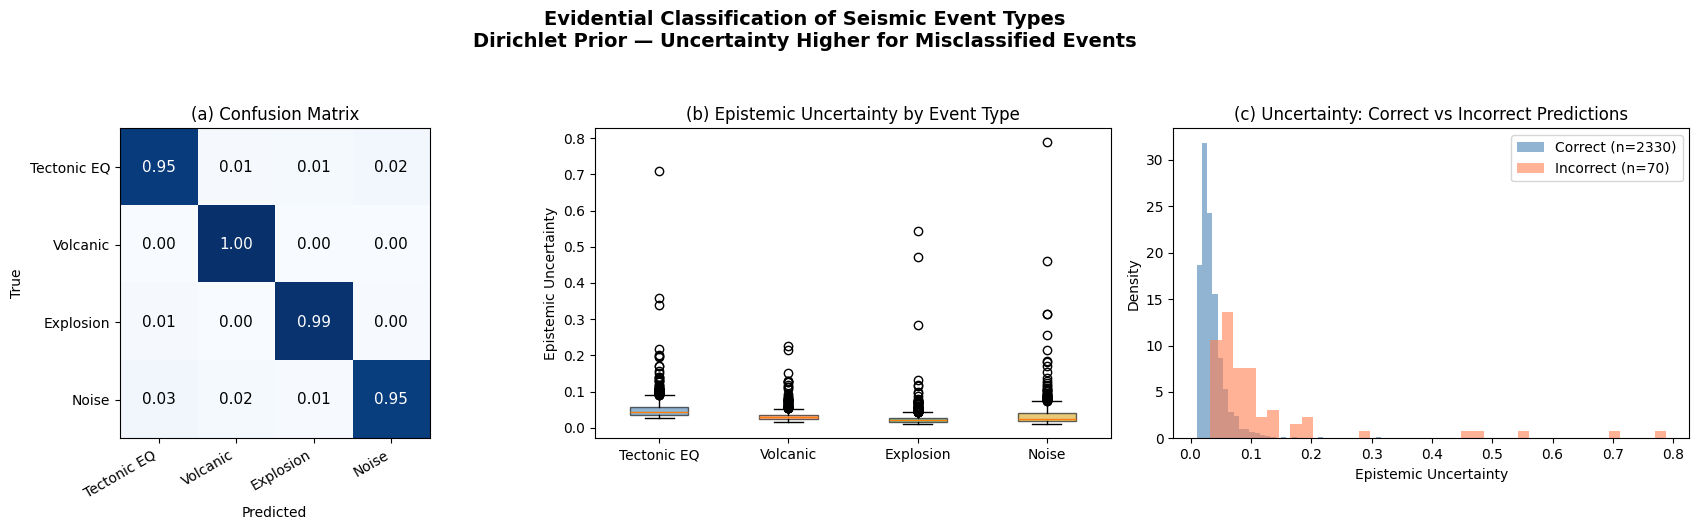

In [ ]:
# Classification results: confusion matrix + uncertainty by class
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Confusion matrix
cm = confusion_matrix(yc_test, pred_cls)
cm_norm = cm / cm.sum(1, keepdims=True)
im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
for i in range(N_CLS):
    for j in range(N_CLS):
        axes[0].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                     color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=11)
axes[0].set_xticks(range(N_CLS)); axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
axes[0].set_yticks(range(N_CLS)); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('(a) Confusion Matrix')

# (b) Epistemic uncertainty by class
bp = axes[1].boxplot([epist_evd[yc_test == i] for i in range(N_CLS)],
                     labels=CLASS_NAMES, patch_artist=True)
colors_cls = ['steelblue', 'coral', 'seagreen', 'goldenrod']
for patch, col in zip(bp['boxes'], colors_cls):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[1].set_ylabel('Epistemic Uncertainty')
axes[1].set_title('(b) Epistemic Uncertainty by Event Type')

# (c) Uncertainty of correct vs incorrect predictions
correct = pred_cls == yc_test
axes[2].hist(epist_evd[correct], bins=40, alpha=0.6, color='steelblue',
             label=f'Correct (n={correct.sum()})', density=True)
axes[2].hist(epist_evd[~correct], bins=40, alpha=0.6, color='coral',
             label=f'Incorrect (n={(~correct).sum()})', density=True)
axes[2].set_xlabel('Epistemic Uncertainty'); axes[2].set_ylabel('Density')
axes[2].set_title('(c) Uncertainty: Correct vs Incorrect Predictions')
axes[2].legend()

fig.suptitle('Evidential Classification of Seismic Event Types\n'
             'Dirichlet Prior — Uncertainty Higher for Misclassified Events',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

---
## Part 13: The MILES-GUESS Package

Schreck et al. developed the [MILES-GUESS](https://github.com/ai2es/miles-guess) Python package to make evidential deep learning accessible for Earth system science. It provides:

- Keras and PyTorch implementations of evidential models
- Training scripts for both regression and classification
- Evaluation tools (calibration, discard tests, attribution)
- Law of Total Variance decomposition utilities

```python
# Installation
!git clone https://github.com/ai2es/miles-guess.git
!cd miles-guess && pip install -e .

# Example usage (PyTorch)
from mlguess.torch.models import EvidentialMLP
from mlguess.torch.losses import EvidentialLoss

# The package supports 4 modes:
# 1. Deterministic MLP (baseline)
# 2. Gaussian MLP (aleatoric only)
# 3. Ensemble of Gaussian MLPs
# 4. Evidential MLP (aleatoric + epistemic)
```

---

## Part 14: Exercises

### Exercise 1: Regularization Coefficient Study (⭐)
Vary the evidential regularization coefficient $\lambda$ from 0 to 1. How does it affect the trade-off between prediction accuracy and uncertainty quality? Reproduce the analysis from Schreck et al. Section 4.

### Exercise 2: Ensemble Size vs Evidential (⭐⭐)
Compare Deep Ensembles with N = 2, 5, 10, 20 members to a single evidential model. At what ensemble size does the ensemble match or exceed evidential DL in calibration quality? Plot training cost vs calibration error.

### Exercise 3: Seismic Phase Picking with UQ (⭐⭐)
Apply evidential regression to predict P-wave and S-wave arrival times from seismic waveform features. The aleatoric uncertainty should capture picking ambiguity (e.g., emergent onsets), while epistemic uncertainty should flag low-SNR or unusual waveforms.

### Exercise 4: Conformal Prediction Baseline (⭐⭐)
Implement conformal prediction as a distribution-free UQ method. Compare its prediction intervals to the parametric intervals from evidential DL. Conformal prediction guarantees finite-sample coverage — does evidential DL achieve similar guarantees empirically?

### Exercise 5: MILES-GUESS on Real Data (⭐⭐⭐)
Install the MILES-GUESS package and reproduce the surface layer flux regression experiment from Schreck et al. using the provided configuration files. Compare your evidential model to the paper's reported metrics.

### Exercise 6: Multivariate Evidential Regression (⭐⭐⭐)
Extend the NIG formulation to predict multiple correlated outputs simultaneously (e.g., PGA and PGV). Use the multivariate evidential regression framework from Meinert & Lavin (2021). How do correlations between target variables affect uncertainty decomposition?

### Exercise 7: Evidential Early Warning (⭐⭐⭐)
Design an earthquake early warning system that uses evidential uncertainty to issue alerts at different confidence levels: issue a warning only when epistemic uncertainty is below a threshold. How does this trade-off affect false alarm rate vs detection probability?

---
## References

1. **Schreck, J. S., Gagne, D. J., II, et al. (2024).** Evidential Deep Learning: Enhancing Predictive Uncertainty Estimation for Earth System Science Applications. *Artificial Intelligence for the Earth Systems*, 3(4). [arXiv:2309.13207](https://arxiv.org/abs/2309.13207)

2. **Amini, A., Schwarting, W., Soleimany, A., & Rus, D. (2020).** Deep Evidential Regression. *NeurIPS 2020*. [arXiv:1910.02600](https://arxiv.org/abs/1910.02600)

3. **Sensoy, M., Kaplan, L., & Kandemir, M. (2018).** Evidential Deep Learning to Quantify Classification Uncertainty. *NeurIPS 2018*.

4. **Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017).** Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles. *NeurIPS 2017*.

5. **Gal, Y. & Ghahramani, Z. (2016).** Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning. *ICML 2016*.

6. **Kendall, A. & Gal, Y. (2017).** What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision? *NeurIPS 2017*.

7. **MILES-GUESS Package.** [github.com/ai2es/miles-guess](https://github.com/ai2es/miles-guess)

8. **edl-pytorch.** [github.com/teddykoker/evidential-learning-pytorch](https://github.com/teddykoker/evidential-learning-pytorch)